# PINN Backbone: 1D Heat Diffusion

**Post-graduate exercise -- IMW 2026.**

This is a *skeleton* notebook. The data-sampling, plotting, and validation code is provided; the core PINN logic is left for you to fill in as `TODO` blocks. Full mathematical background is in `pinn_heat_equation.tex` -- read it first.

PDE: $u_t = \alpha\, u_{xx}$ on $x \in [0,1]$, $t \in [0,1]$.
IC: $u(x,0) = \sin(\pi x)$. BC: $u(0,t) = u(1,t) = 0$.
Exact solution (for validation only): $u(x,t) = \sin(\pi x)\, e^{-\alpha \pi^2 t}$.

In [60]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism() # deterministic

ALPHA = 0.1
L = 1.0
T = 1.0

def exact_solution(x, t):
    """Ground-truth analytical solution -- validation only, do not use during training."""
    return np.sin(np.pi * x) * np.exp(-ALPHA * (np.pi ** 2) * t)

## 1. Sample training points (provided)

Interior collocation points (`x_f, t_f`), initial-condition points (`x_ic, t_ic, u_ic`), and boundary points (`x_bc_left, x_bc_right, t_bc, u_bc`). See Eqs. (7)-(9) in the tex document.

In [61]:
N_COLLOCATION = 2000
N_IC = 200
N_BC = 200

x_f = np.random.uniform(0, L, (N_COLLOCATION, 1))
t_f = np.random.uniform(0, T, (N_COLLOCATION, 1))

x_ic = np.random.uniform(0, L, (N_IC, 1))
t_ic = np.zeros((N_IC, 1))
u_ic = np.sin(np.pi * x_ic)

t_bc = np.random.uniform(0, T, (N_BC, 1))
x_bc_left = np.zeros((N_BC, 1))
x_bc_right = np.ones((N_BC, 1))
u_bc = np.zeros((N_BC, 1))

to_tf = lambda arr: tf.convert_to_tensor(arr, dtype=tf.float32)
x_f, t_f = to_tf(x_f), to_tf(t_f)
x_ic, t_ic, u_ic = to_tf(x_ic), to_tf(t_ic), to_tf(u_ic)
x_bc_left, x_bc_right, t_bc, u_bc = to_tf(x_bc_left), to_tf(x_bc_right), to_tf(t_bc), to_tf(u_bc)

print(f"Collocation points: {x_f.shape[0]}, IC points: {x_ic.shape[0]}, BC points/side: {x_bc_left.shape[0]}")

Collocation points: 2000, IC points: 200, BC points/side: 200


## 2. TODO: build the network

Build a fully-connected MLP: 2 inputs `(x, t)` -> several hidden layers -> 1 output `u`.

Requirements (see Section 4 of the tex document):
- Use a **smooth** activation (`tanh`), not ReLU -- the physics loss needs a nonzero second derivative.
- Suggested defaults: 4 hidden layers, 40 units each, `glorot_normal` initializer.
- Input shape `(2,)`, output shape `(1,)`.

In [62]:
def build_pinn(n_layers=4, n_units=40):
    inputs = tf.keras.Input(shape=(2,))
    x = inputs
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(
            n_units,
            activation="tanh"
        )(x)
    outputs = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)
    # raise NotImplementedError("Build the MLP here.")

model = build_pinn()
model.summary()

Model: "functional_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_56 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_290 (Dense)               │ (None, 40)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_294 (Dense)               │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,081 (19.85 KB)

 Trainable params: 5,081 (19.85 KB)

 Non-trainable params: 0 (0.00 B)

## 3. TODO: PDE residual via automatic differentiation

Implement Eq. (6) from the tex document:

$$ f_\theta(x,t) = \frac{\partial u_\theta}{\partial t} - \alpha \frac{\partial^2 u_\theta}{\partial x^2} $$

Hints:
- You need **two nested** `tf.GradientTape(persistent=True)` contexts: the outer one to get the second derivative `u_xx`, the inner one to get first derivatives `u_x` and `u_t`.
- Both tapes must `watch(x)` and `watch(t)` explicitly, since `x` and `t` are plain tensors, not `tf.Variable`s.
- Remember to `del` persistent tapes when done to free memory.

In [63]:
def pde_residual(model, x, t):
    """Returns f = u_t - ALPHA * u_xx at the given (x, t) points."""
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u = model(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
    u_xx = tape2.gradient(u_x, x)
    del tape1, tape2
    return u_t - ALPHA * u_xx


## 4. TODO: assemble the total loss and training step

Implement Eqs. (7)-(10): PDE residual loss + IC loss + BC loss (equal weights = 1 to start). Use `tf.reduce_mean(tf.square(...))` for each term.

In [64]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        f_pred = pde_residual(model, x_f, t_f)
        loss_pde = tf.reduce_mean(tf.square(f_pred))

        u_ic_pred = model(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic))

        u_bc_left_pred = model(tf.concat([x_bc_left, t_bc], axis=1))
        u_bc_right_pred = model(tf.concat([x_bc_right, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_bc_left_pred - u_bc)) + \
                  tf.reduce_mean(tf.square(u_bc_right_pred - u_bc))

        loss = loss_pde + loss_ic + loss_bc

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_bc


## 5. Training loop (provided)

Once cells 2-4 above are implemented, this should run and the loss components should decrease. If `loss_pde` stays flat while `loss_ic`/`loss_bc` drop to zero, check your residual implementation (Section 3) first -- that is the most common bug.

In [65]:
EPOCHS = 5000
history = {'loss': [], 'loss_pde': [], 'loss_ic': [], 'loss_bc': []}

for epoch in range(EPOCHS):
    loss, loss_pde, loss_ic, loss_bc = train_step()
    history['loss'].append(float(loss))
    history['loss_pde'].append(float(loss_pde))
    history['loss_ic'].append(float(loss_ic))
    history['loss_bc'].append(float(loss_bc))
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | total {loss:.2e} | pde {loss_pde:.2e} | "
              f"ic {loss_ic:.2e} | bc {loss_bc:.2e}")

Epoch     0 | total 1.19e+00 | pde 1.72e-01 | ic 8.91e-01 | bc 1.23e-01
Epoch   500 | total 1.76e-03 | pde 6.76e-04 | ic 5.08e-04 | bc 5.80e-04
Epoch  1000 | total 7.00e-04 | pde 3.65e-04 | ic 1.37e-04 | bc 1.98e-04
Epoch  1500 | total 3.74e-04 | pde 2.40e-04 | ic 4.57e-05 | bc 8.83e-05
Epoch  2000 | total 2.28e-04 | pde 1.63e-04 | ic 2.36e-05 | bc 4.12e-05
Epoch  2500 | total 1.44e-04 | pde 1.02e-04 | ic 1.01e-05 | bc 3.17e-05
Epoch  3000 | total 7.95e-04 | pde 1.06e-04 | ic 2.50e-04 | bc 4.39e-04
Epoch  3500 | total 7.06e-05 | pde 4.99e-05 | ic 4.40e-06 | bc 1.63e-05
Epoch  4000 | total 5.67e-05 | pde 3.93e-05 | ic 5.69e-06 | bc 1.17e-05
Epoch  4500 | total 4.09e-05 | pde 2.83e-05 | ic 2.80e-06 | bc 9.75e-06


## 6. Diagnostics and validation (provided)

Run this once training works. Do not modify -- use it to check your implementation.

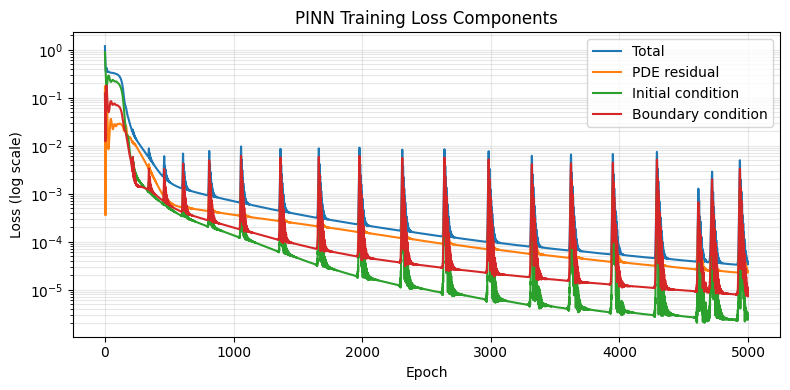

Max absolute error: 9.2694e-03
Mean absolute error: 1.2821e-03


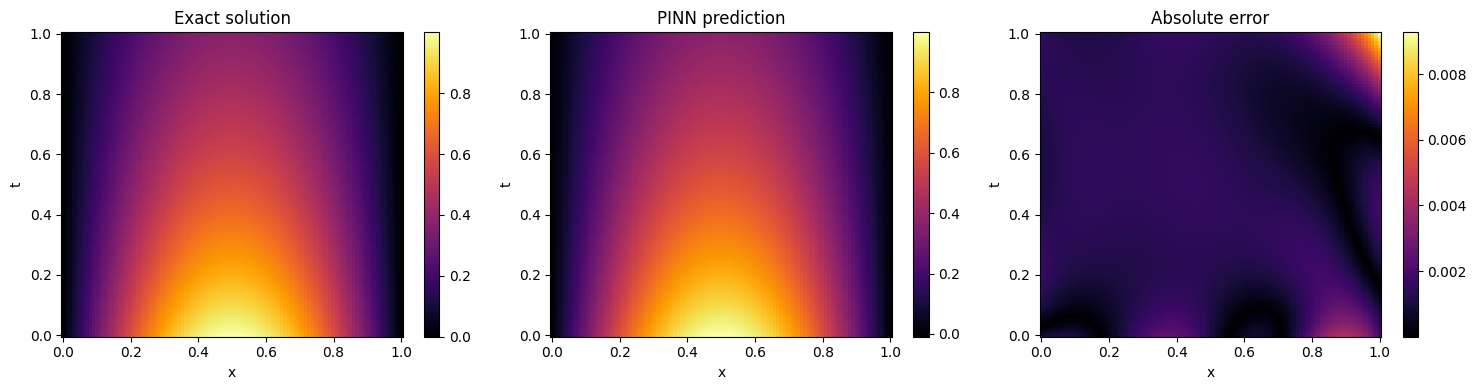

In [66]:
plt.figure(figsize=(8, 4))
plt.semilogy(history['loss'], label='Total')
plt.semilogy(history['loss_pde'], label='PDE residual')
plt.semilogy(history['loss_ic'], label='Initial condition')
plt.semilogy(history['loss_bc'], label='Boundary condition')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Loss Components')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

n_grid = 100
x_grid = np.linspace(0, L, n_grid)
t_grid = np.linspace(0, T, n_grid)
X, Tm = np.meshgrid(x_grid, t_grid)
xt_flat = np.stack([X.flatten(), Tm.flatten()], axis=1).astype(np.float32)
u_pred = model(xt_flat).numpy().reshape(n_grid, n_grid)
u_exact = exact_solution(X, Tm)
abs_error = np.abs(u_pred - u_exact)
print(f"Max absolute error: {abs_error.max():.4e}")
print(f"Mean absolute error: {abs_error.mean():.4e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes, [u_exact, u_pred, abs_error],
                           ['Exact solution', 'PINN prediction', 'Absolute error']):
    im = ax.pcolormesh(X, Tm, data, shading='auto', cmap='inferno')
    ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. Snapshot comparison at fixed times (provided)

A second, complementary view of the same result: fixed-time slices of $u(x,t)$, exact vs. PINN, overlaid. Useful for spotting whether errors are concentrated near $t=0$ (an IC-fitting problem) or grow over time (an accumulating-residual problem).

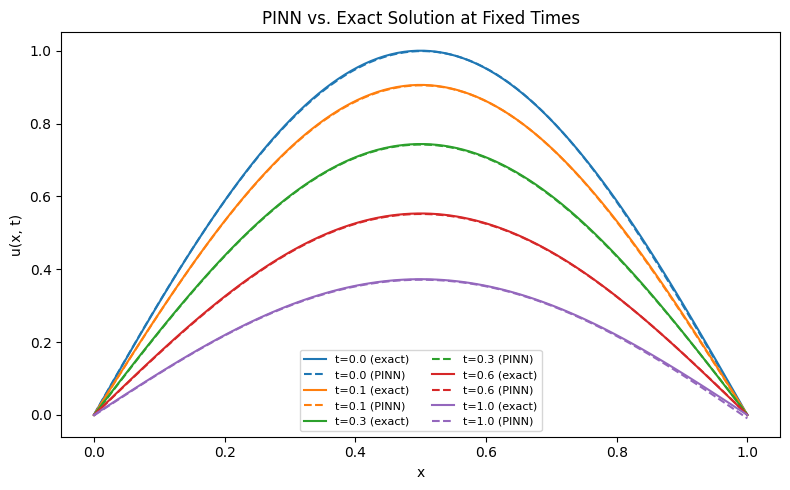

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
for t_snap in [0.0, 0.1, 0.3, 0.6, 1.0]:
    xt_snap = np.stack([x_grid, np.full_like(x_grid, t_snap)], axis=1).astype(np.float32)
    u_snap_pred = model(xt_snap).numpy().flatten()
    u_snap_exact = exact_solution(x_grid, t_snap)
    line, = ax.plot(x_grid, u_snap_exact, '-', label=f't={t_snap} (exact)')
    ax.plot(x_grid, u_snap_pred, '--', color=line.get_color(), label=f't={t_snap} (PINN)')
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('PINN vs. Exact Solution at Fixed Times')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 8. Now attempt the exercises

See Section 6 ("Exercises") of `pinn_heat_equation.tex` for the full description of Exercises A-E (collocation density, loss weighting, inverse problem, Burgers' equation, numerical baseline comparison). Duplicate this notebook per exercise and modify the relevant TODO cells above.

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

### Exercise A. Sensitivity to collocation density

In [150]:
L = 1.0
T = 1.0
N_COLLOCATION = 2000
N_IC = 200
N_BC = 200
# Collocation points
x_f = np.random.uniform(0, L, (N_COLLOCATION, 1))
t_f = np.random.uniform(0, T, (N_COLLOCATION, 1))
# Heat Equation Initial Condition (Positive Sine)
x_ic = np.random.uniform(0, L, (N_IC, 1))
t_ic = np.zeros((N_IC, 1))
u_ic = np.sin(np.pi * x_ic)
# Heat Equation Boundary Conditions (at x=0 and x=1)
t_bc = np.random.uniform(0, T, (N_BC, 1))
x_bc_left = np.zeros((N_BC, 1))
x_bc_right = np.ones((N_BC, 1))
u_bc = np.zeros((N_BC, 1))
to_tf = lambda arr: tf.convert_to_tensor(arr, dtype=tf.float32)
x_f, t_f = to_tf(x_f), to_tf(t_f)
x_ic, t_ic, u_ic = to_tf(x_ic), to_tf(t_ic), to_tf(u_ic)
x_bc_left, x_bc_right, t_bc, u_bc = to_tf(x_bc_left), to_tf(x_bc_right), to_tf(t_bc), to_tf(u_bc)


--- Training with N_f = 100 ---
Epoch     0 | total 5.89e-01 | pde 1.40e-02
Epoch  1000 | total 6.53e-04 | pde 2.84e-04
Epoch  2000 | total 1.85e-03 | pde 1.90e-04
Epoch  3000 | total 1.15e-04 | pde 4.97e-05
Epoch  4000 | total 1.29e-03 | pde 6.80e-05
Training time: 15.57 seconds
Max absolute error for N_f=100: 2.0007e+00

--- Training with N_f = 500 ---
Epoch     0 | total 6.39e-01 | pde 2.72e-03
Epoch  1000 | total 6.73e-04 | pde 2.76e-04
Epoch  2000 | total 4.27e-04 | pde 1.89e-04
Epoch  3000 | total 3.45e-04 | pde 1.50e-04
Epoch  4000 | total 4.31e-04 | pde 1.19e-04
Training time: 31.39 seconds
Max absolute error for N_f=500: 2.0050e+00

--- Training with N_f = 2000 ---
Epoch     0 | total 7.76e-01 | pde 5.22e-02
Epoch  1000 | total 6.88e-04 | pde 3.03e-04
Epoch  2000 | total 6.56e-04 | pde 1.94e-04
Epoch  3000 | total 1.79e-03 | pde 2.54e-04
Epoch  4000 | total 2.20e-04 | pde 1.11e-04
Training time: 65.83 seconds
Max absolute error for N_f=2000: 2.0030e+00

--- Training with N_f 

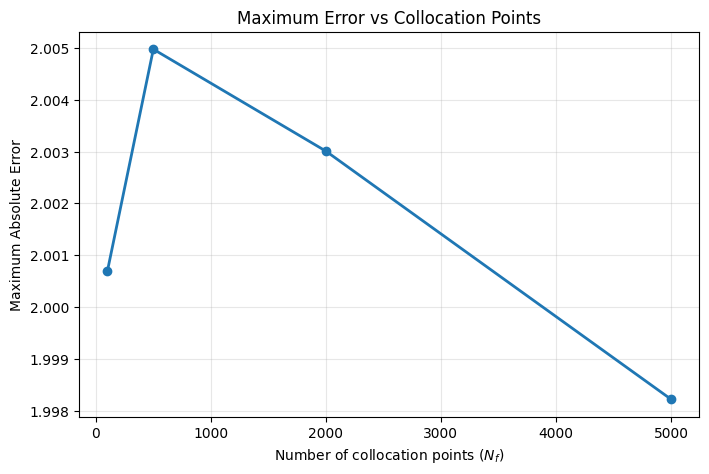

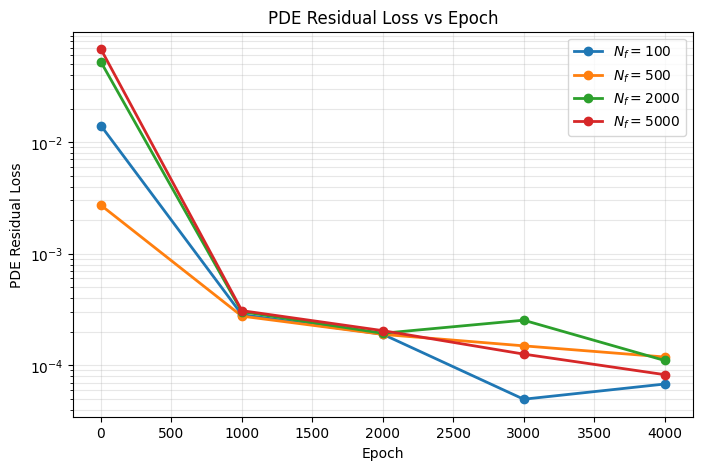

In [117]:
import time

np.random.seed(10124010)
tf.random.set_seed(10124010)

N_f_list = [100, 500, 2000, 5000]
max_errors = []
models_A = []

training_times = []

# Store PDE residual every 1000 epochs
pde_loss_history = {}

for N_f in N_f_list:
    print(f"\n--- Training with N_f = {N_f} ---")

    x_f_i = np.random.uniform(0, L, (N_f, 1))
    t_f_i = np.random.uniform(0, T, (N_f, 1))
    x_f_tf = to_tf(x_f_i)
    t_f_tf = to_tf(t_f_i)

    model_A = build_pinn()
    models_A.append(model_A)

    optimizer_A = tf.keras.optimizers.Adam(learning_rate=1e-3)

    @tf.function
    def train_step_A():
        with tf.GradientTape() as tape:
            f_pred = pde_residual(model_A, x_f_tf, t_f_tf)
            loss_pde = tf.reduce_mean(tf.square(f_pred))

            u_ic_pred = model_A(tf.concat([x_ic, t_ic], axis=1))
            loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic))

            u_bc_left_pred = model_A(tf.concat([x_bc_left, t_bc], axis=1))
            u_bc_right_pred = model_A(tf.concat([x_bc_right, t_bc], axis=1))
            loss_bc = (
                tf.reduce_mean(tf.square(u_bc_left_pred - u_bc))
                + tf.reduce_mean(tf.square(u_bc_right_pred - u_bc))
            )

            loss = loss_pde + loss_ic + loss_bc

        grads = tape.gradient(loss, model_A.trainable_variables)
        optimizer_A.apply_gradients(zip(grads, model_A.trainable_variables))

        return loss, loss_pde, loss_ic, loss_bc

    EPOCHS = 5000
    
    # Store PDE residual every 1000 epochs
    pde_history = []

    start_time = time.perf_counter()
    for epoch in range(EPOCHS):
        loss_A, loss_pde_A, loss_ic_A, loss_bc_A = train_step_A()

        if epoch % 1000 == 0:
            print(
                f"Epoch {epoch:5d} | total {loss_A:.2e} | pde {loss_pde_A:.2e}"
            )
            pde_history.append(loss_pde_A.numpy())
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    training_times.append(elapsed_time)

    print(f"Training time: {elapsed_time:.2f} seconds")

    pde_loss_history[N_f] = pde_history

    # Evaluate
    n_grid_A = 100
    x_grid_A = np.linspace(0, L, n_grid_A)
    t_grid_A = np.linspace(0, T, n_grid_A)
    X_A, Tm_A = np.meshgrid(x_grid_A, t_grid_A)

    xt_flat_A = np.stack(
        [X_A.flatten(), Tm_A.flatten()], axis=1
    ).astype(np.float32)

    u_pred_A = model_A(xt_flat_A).numpy().reshape(n_grid_A, n_grid_A)
    u_exact_A = exact_solution(X_A, Tm_A)

    abs_error_A = np.abs(u_pred_A - u_exact_A)
    max_err = abs_error_A.max()

    print(f"Max absolute error for N_f={N_f}: {max_err:.4e}")

    max_errors.append(max_err)

# Maximum Error vs Collocation Points
plt.figure(figsize=(8,5))
plt.plot(N_f_list, max_errors, marker='o', linewidth=2)
plt.xlabel("Number of collocation points ($N_f$)")
plt.ylabel("Maximum Absolute Error")
plt.title("Maximum Error vs Collocation Points")
plt.grid(True, alpha=0.3)
plt.show()

# PDE residual loss
epochs = [0, 1000, 2000, 3000, 4000]

plt.figure(figsize=(8,5))

for N_f in N_f_list:
    plt.plot(
        epochs,
        pde_loss_history[N_f],
        marker='o',
        linewidth=2,
        label=f"$N_f={N_f}$"
    )

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("PDE Residual Loss")
plt.title("PDE Residual Loss vs Epoch")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Exercise B. Loss weighting

In [151]:
np.random.seed(10124010)
tf.random.set_seed(10124010)

weight_sets = [
    (1, 1, 1),
    (1, 10, 10),
    (1, 100, 100)
]

def train_pinn(wf, w0, wb):

    N_f = 2000
    EPOCHS = 5000

    # Collocation points
    x_f = np.random.uniform(0, L, (N_f,1))
    t_f = np.random.uniform(0, T, (N_f,1))

    x_f = to_tf(x_f)
    t_f = to_tf(t_f)

    model = build_pinn()
    optimizer = tf.keras.optimizers.Adam(1e-3)

    @tf.function
    def train_step():

        with tf.GradientTape() as tape:

            # PDE
            f_pred = pde_residual(model, x_f, t_f)
            loss_pde = tf.reduce_mean(tf.square(f_pred))

            # initial condition
            u_ic_pred = model(tf.concat([x_ic, t_ic], axis=1))
            loss_ic = tf.reduce_mean(tf.square(u_ic_pred-u_ic))

            # boundary conditions
            u_left = model(tf.concat([x_bc_left, t_bc], axis=1))
            u_right = model(tf.concat([x_bc_right, t_bc], axis=1))

            loss_bc = (
                tf.reduce_mean(tf.square(u_left-u_bc))
                + tf.reduce_mean(tf.square(u_right-u_bc))
            )

            # weighted loss
            loss = (
                    wf*loss_pde
                +   w0*loss_ic
                +   wb*loss_bc
            )

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        return loss, loss_pde, loss_ic, loss_bc

    print(f"\nTraining (wf,w0,wb)=({wf},{w0},{wb})")

    for epoch in range(EPOCHS):

        loss, lpde, lic, lbc = train_step()

        if epoch % 1000 == 0:
            print(
                f"Epoch {epoch:5d}"
                f" | total {loss:.2e}"
                f" | PDE {lpde:.2e}"
                f" | IC {lic:.2e}"
                f" | BC {lbc:.2e}"
            )

    return model

# training models
models = {}
for wf, w0, wb in weight_sets:
    models[(wf,w0,wb)] = train_pinn(wf,w0,wb)


Training (wf,w0,wb)=(1,1,1)
Epoch     0 | total 6.91e-01 | PDE 1.22e-01 | IC 4.39e-01 | BC 1.30e-01
Epoch  1000 | total 7.78e-03 | PDE 7.65e-04 | IC 1.69e-03 | BC 5.32e-03
Epoch  2000 | total 1.47e-04 | PDE 8.20e-05 | IC 1.80e-05 | BC 4.73e-05
Epoch  3000 | total 5.03e-05 | PDE 3.69e-05 | IC 2.02e-06 | BC 1.13e-05
Epoch  4000 | total 2.22e-05 | PDE 1.79e-05 | IC 4.04e-07 | BC 3.85e-06

Training (wf,w0,wb)=(1,10,10)
Epoch     0 | total 4.53e+00 | PDE 1.01e-02 | IC 3.93e-01 | BC 5.93e-02
Epoch  1000 | total 3.23e-03 | PDE 1.85e-03 | IC 7.53e-05 | BC 6.25e-05
Epoch  2000 | total 1.66e-03 | PDE 1.10e-03 | IC 3.01e-05 | BC 2.59e-05
Epoch  3000 | total 1.05e-03 | PDE 7.27e-04 | IC 1.67e-05 | BC 1.53e-05
Epoch  4000 | total 5.51e-04 | PDE 3.92e-04 | IC 7.42e-06 | BC 8.49e-06

Training (wf,w0,wb)=(1,100,100)
Epoch     0 | total 4.81e+01 | PDE 1.13e-03 | IC 4.80e-01 | BC 1.39e-03
Epoch  1000 | total 2.93e-02 | PDE 8.16e-03 | IC 1.52e-04 | BC 6.00e-05
Epoch  2000 | total 9.43e-03 | PDE 4.60e-03

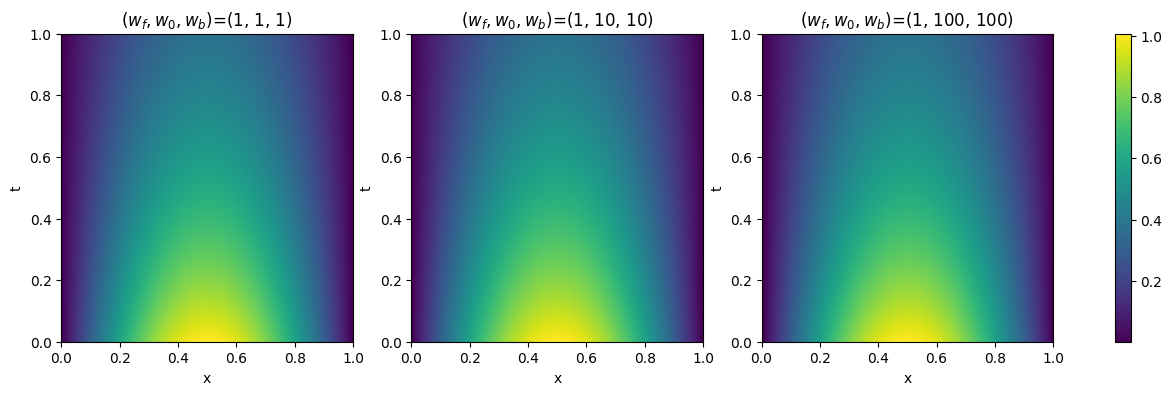

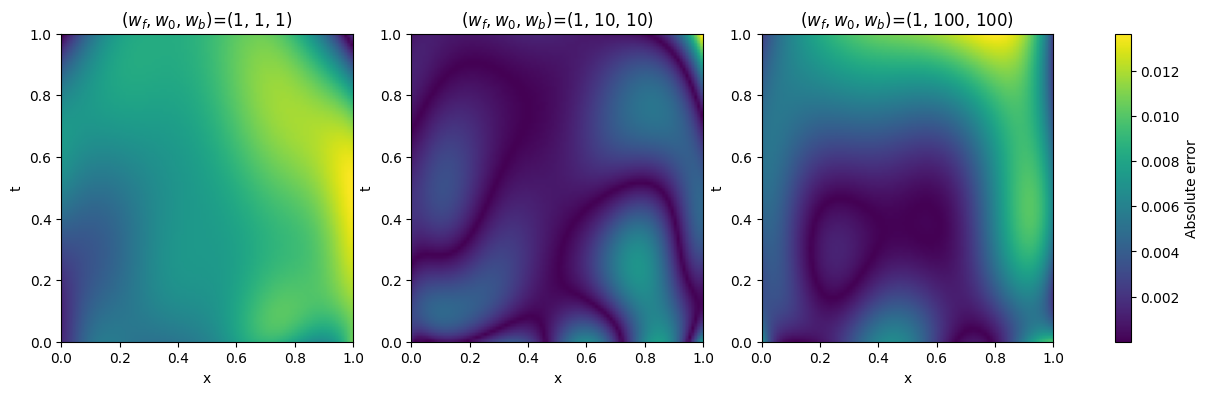

In [152]:
n_grid = 100

x = np.linspace(0,L,n_grid)
t = np.linspace(0,T,n_grid)

X,Tm = np.meshgrid(x,t)

xt = np.stack(
    [X.flatten(),Tm.flatten()],
    axis=1
).astype(np.float32)

u_exact = exact_solution(X,Tm)

fig, axes = plt.subplots(1,3,figsize=(16,4))

for ax, key in zip(axes, weight_sets):

    model = models[key]

    u_pred = model(xt).numpy().reshape(n_grid,n_grid)

    im = ax.imshow(
        u_pred,
        origin="lower",
        extent=[0,L,0,T],
        aspect="auto"
    )

    ax.set_title(f"$(w_f,w_0,w_b)$={key}")
    ax.set_xlabel("x")
    ax.set_ylabel("t")

fig.colorbar(im, ax=axes)
plt.show()

fig, axes = plt.subplots(1,3,figsize=(16,4))

for ax, key in zip(axes, weight_sets):

    model = models[key]

    u_pred = model(xt).numpy().reshape(n_grid,n_grid)

    err = np.abs(u_pred-u_exact)

    im = ax.imshow(
        err,
        origin="lower",
        extent=[0,L,0,T],
        aspect="auto"
    )

    ax.set_title(f"$(w_f,w_0,w_b)$={key}")
    ax.set_xlabel("x")
    ax.set_ylabel("t")

fig.colorbar(im, ax=axes,label="Absolute error")
plt.show()

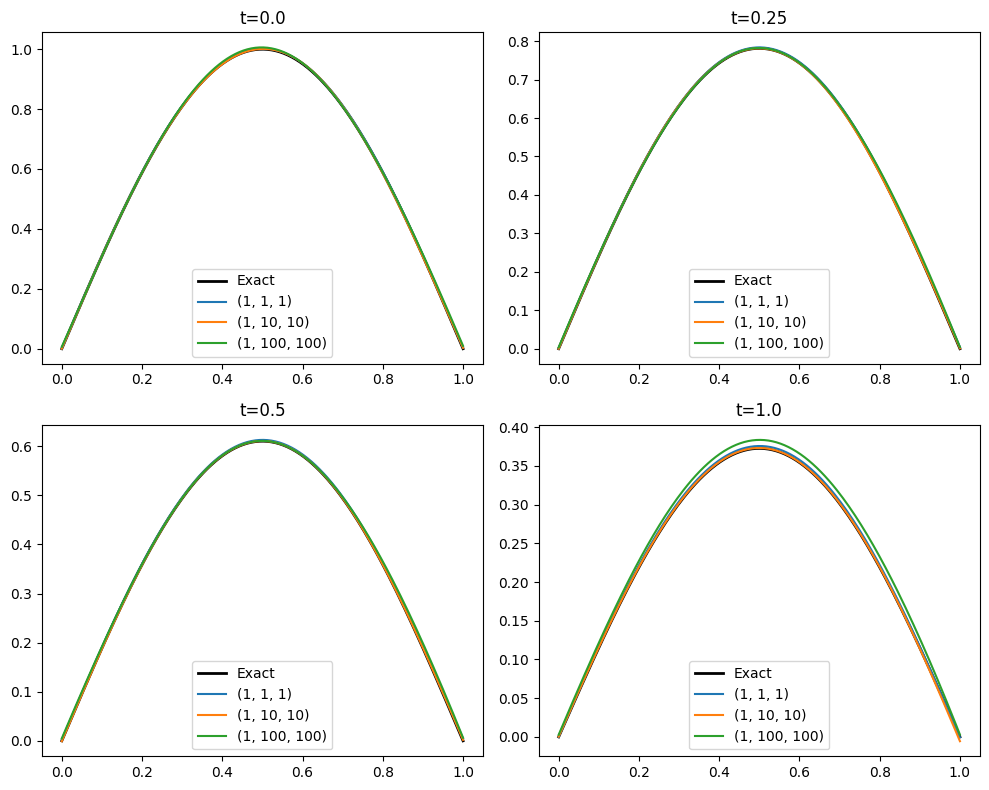

In [153]:
times = [0.0, 0.25, 0.5, 1.0]

fig, axes = plt.subplots(2,2,figsize=(10,8))

for ax, t0 in zip(axes.ravel(), times):

    x_plot = np.linspace(0,L,200)

    ax.plot(
        x_plot,
        exact_solution(x_plot,t0),
        'k',
        linewidth=2,
        label="Exact"
    )

    xt = np.column_stack([
        x_plot,
        np.full_like(x_plot,t0)
    ]).astype(np.float32)

    for key in weight_sets:

        u = models[key](xt).numpy().flatten()

        ax.plot(
            x_plot,
            u,
            label=str(key)
        )

    ax.set_title(f"t={t0}")
    ax.legend()

plt.tight_layout()
plt.show()

### Exercise C.

Epoch     0 | total 1.55e+00 | data 4.30e-01 | alpha = 0.5010
Epoch  1000 | total 3.35e-03 | data 2.96e-03 | alpha = 0.0938
Epoch  2000 | total 3.14e-03 | data 2.96e-03 | alpha = 0.0945
Epoch  3000 | total 3.07e-03 | data 2.97e-03 | alpha = 0.0948
Epoch  4000 | total 3.05e-03 | data 2.97e-03 | alpha = 0.0949
Epoch  5000 | total 3.04e-03 | data 2.98e-03 | alpha = 0.0950
Epoch  6000 | total 3.03e-03 | data 2.98e-03 | alpha = 0.0950
Epoch  7000 | total 3.06e-03 | data 2.99e-03 | alpha = 0.0950
Final estimated ALPHA: 0.0950 (True value: 0.1)


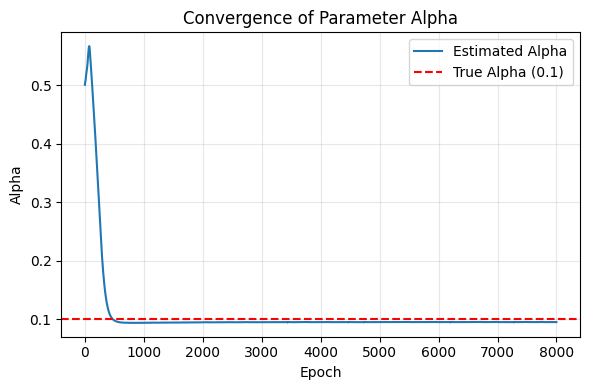

In [73]:
# initialize ALPHA as a trainable variable and guess a value
ALPHA_var = tf.Variable(initial_value=0.5, trainable=True, dtype=tf.float32)

# generate noisy sensor data
N_sensor = 50
x_sensor = np.random.uniform(0, L, (N_sensor, 1))
t_sensor = np.random.uniform(0, T, (N_sensor, 1))
u_sensor_clean = exact_solution(x_sensor, t_sensor)
noise = np.random.normal(0, 0.05, u_sensor_clean.shape) # 5% noise
u_sensor = u_sensor_clean + noise

x_sensor_tf = to_tf(x_sensor)
t_sensor_tf = to_tf(t_sensor)
u_sensor_tf = to_tf(u_sensor)

model_C = build_pinn()
optimizer_C = tf.keras.optimizers.Adam(learning_rate=1e-3)

def pde_residual_C(model, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u = model(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
    u_xx = tape2.gradient(u_x, x)
    del tape1, tape2
    return u_t - ALPHA_var * u_xx

@tf.function
def train_step_C():
    with tf.GradientTape() as tape:
        f_pred = pde_residual_C(model_C, x_f, t_f)
        loss_pde = tf.reduce_mean(tf.square(f_pred))

        u_ic_pred = model_C(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic))

        u_bc_left_pred = model_C(tf.concat([x_bc_left, t_bc], axis=1))
        u_bc_right_pred = model_C(tf.concat([x_bc_right, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_bc_left_pred - u_bc)) + \
                  tf.reduce_mean(tf.square(u_bc_right_pred - u_bc))

        u_sensor_pred = model_C(tf.concat([x_sensor_tf, t_sensor_tf], axis=1))
        loss_data = tf.reduce_mean(tf.square(u_sensor_pred - u_sensor_tf))

        loss = loss_pde + loss_ic + loss_bc + loss_data

    trainable_vars = model_C.trainable_variables + [ALPHA_var]
    grads = tape.gradient(loss, trainable_vars)
    optimizer_C.apply_gradients(zip(grads, trainable_vars))
    return loss, loss_data, ALPHA_var

EPOCHS_C = 8000
alpha_history = []
for epoch in range(EPOCHS_C):
    loss_C, loss_data_C, alpha_val = train_step_C()
    alpha_history.append(float(alpha_val))
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | total {loss_C:.2e} | data {loss_data_C:.2e} | alpha = {alpha_val:.4f}")

print(f"Final estimated ALPHA: {alpha_history[-1]:.4f} (True value: 0.1)")

plt.figure(figsize=(6, 4))
plt.plot(alpha_history, label='Estimated Alpha')
plt.axhline(y=0.1, color='r', linestyle='--', label='True Alpha (0.1)')
plt.xlabel('Epoch')
plt.ylabel('Alpha')
plt.title('Convergence of Parameter Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Exercise D

In [103]:
NU = 0.01 / np.pi
L = 1.0 # domain is [-1, 1]
T = 1.0

# Collocation points
N_f = 2000
N_ic = 500
N_bc = 500

x_f = np.random.uniform(-L, L, (N_f, 1))
t_f = np.random.uniform(0, T, (N_f, 1))

x_ic = np.random.uniform(-L, L, (N_ic, 1))
t_ic = np.zeros((N_ic, 1))
u_ic = -np.sin(np.pi * x_ic)

t_bc = np.random.uniform(0, T, (N_bc, 1))
x_bc_left = -np.ones((N_bc, 1))
x_bc_right = np.ones((N_bc, 1))
u_bc = np.zeros((N_bc, 1))

x_f, t_f = to_tf(x_f), to_tf(t_f)
x_ic, t_ic, u_ic = to_tf(x_ic), to_tf(t_ic), to_tf(u_ic)
x_bc_left, x_bc_right, t_bc, u_bc = to_tf(x_bc_left), to_tf(x_bc_right), to_tf(t_bc), to_tf(u_bc)

def pde_residual_burgers(model_to_use, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u = model_to_use(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
    u_xx = tape2.gradient(u_x, x)
    del tape1, tape2
    return u_t + u * u_x - NU * u_xx

print("-- Training Original PINN (4 layers, 40 units) --")
model_shallow = build_pinn(n_layers=4, n_units=40)
optimizer_shallow = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step_shallow():
    with tf.GradientTape() as tape:
        f_pred = pde_residual_burgers(model_shallow, x_f, t_f)
        loss_pde = tf.reduce_mean(tf.square(f_pred))

        u_ic_pred = model_shallow(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic))

        u_bc_left_pred = model_shallow(tf.concat([x_bc_left, t_bc], axis=1))
        u_bc_right_pred = model_shallow(tf.concat([x_bc_right, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_bc_left_pred - u_bc)) + \
                  tf.reduce_mean(tf.square(u_bc_right_pred - u_bc))

        loss = loss_pde + loss_ic + loss_bc

    grads = tape.gradient(loss, model_shallow.trainable_variables)
    optimizer_shallow.apply_gradients(zip(grads, model_shallow.trainable_variables))
    return loss, loss_pde, loss_ic, loss_bc

EPOCHS = 5000
for epoch in range(EPOCHS):
    loss, loss_pde, loss_ic, loss_bc = train_step_shallow()
    if epoch % 1000 == 0:
        print(f"Shallow PINN Epoch {epoch:5d} | total {loss:.2e} | pde {loss_pde:.2e} | ic {loss_ic:.2e} | bc {loss_bc:.2e}")

-- Training Original PINN (4 layers, 40 units) --
Shallow PINN Epoch     0 | total 1.23e+00 | pde 4.36e-01 | ic 4.17e-01 | bc 3.77e-01
Shallow PINN Epoch  1000 | total 9.10e-02 | pde 3.99e-02 | ic 4.96e-02 | bc 1.39e-03
Shallow PINN Epoch  2000 | total 2.16e-02 | pde 9.94e-03 | ic 1.12e-02 | bc 4.80e-04
Shallow PINN Epoch  3000 | total 8.02e-02 | pde 5.00e-02 | ic 2.72e-02 | bc 2.98e-03
Shallow PINN Epoch  4000 | total 1.21e-02 | pde 5.72e-03 | ic 6.34e-03 | bc 7.35e-05


In [111]:
print("-- Training Deep PINN (6 layers, 40 units) --")

model_deep = build_pinn(n_layers=6, n_units=40)
optimizer_deep = tf.keras.optimizers.Adam(learning_rate=1e-3)

N_f = 5000
N_ic = 500
N_bc = 500

# Initial condition
x_ic = tf.random.uniform((N_ic, 1), -L, L)
t_ic = tf.zeros((N_ic, 1), dtype=tf.float32)
u_ic = -tf.sin(np.pi * x_ic)

# Boundary conditions
t_bc = tf.random.uniform((N_bc, 1), 0, T)
x_bc_left = -L * tf.ones((N_bc, 1), dtype=tf.float32)
x_bc_right = L * tf.ones((N_bc, 1), dtype=tf.float32)
u_bc = tf.zeros((N_bc, 1), dtype=tf.float32)

# Collocation points 70% uniform + 30% concentrated near x = 0

N_uniform = int(0.7 * N_f)
N_center = N_f - N_uniform

x_uniform = np.random.uniform(-L, L, (N_uniform, 1))

sigma = 0.2 * L
x_center = np.random.normal(0.0, sigma, (N_center, 1))
x_center = np.clip(x_center, -L, L)

x_f_np = np.vstack([x_uniform, x_center])
np.random.shuffle(x_f_np)

t_f_np = np.random.uniform(0, T, (N_f, 1))

x_f = tf.convert_to_tensor(x_f_np, dtype=tf.float32)
t_f = tf.convert_to_tensor(t_f_np, dtype=tf.float32)

@tf.function
def train_step_deep():

    with tf.GradientTape() as tape:

        f_pred = pde_residual_burgers(model_deep, x_f, t_f)
        loss_pde = tf.reduce_mean(tf.square(f_pred))

        u_ic_pred = model_deep(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic))

        u_bc_left_pred = model_deep(tf.concat([x_bc_left, t_bc], axis=1))
        u_bc_right_pred = model_deep(tf.concat([x_bc_right, t_bc], axis=1))

        loss_bc = (
            tf.reduce_mean(tf.square(u_bc_left_pred - u_bc))
            + tf.reduce_mean(tf.square(u_bc_right_pred - u_bc))
        )

        # (wf, w0, wb) = (1, 10, 10)
        loss = loss_pde + 10.0 * loss_ic + 10.0 * loss_bc

    grads = tape.gradient(loss, model_deep.trainable_variables)
    optimizer_deep.apply_gradients(zip(grads, model_deep.trainable_variables))

    return loss, loss_pde, loss_ic, loss_bc

EPOCHS = 10000
for epoch in range(EPOCHS):
    loss, loss_pde, loss_ic, loss_bc = train_step_deep()
    if epoch % 1000 == 0:
        print(
            f"Deep PINN Epoch {epoch:5d} | "
            f"total {loss:.2e} | "
            f"pde {loss_pde:.2e} | "
            f"ic {loss_ic:.2e} | "
            f"bc {loss_bc:.2e}"
        )

-- Training Deep PINN (6 layers, 40 units) --
Deep PINN Epoch     0 | total 4.70e+00 | pde 3.91e-02 | ic 3.80e-01 | bc 8.58e-02
Deep PINN Epoch  1000 | total 2.78e-01 | pde 2.20e-01 | ic 5.71e-03 | bc 8.26e-05
Deep PINN Epoch  2000 | total 2.18e-01 | pde 1.73e-01 | ic 4.52e-03 | bc 2.42e-05
Deep PINN Epoch  3000 | total 2.42e-02 | pde 1.86e-02 | ic 5.06e-04 | bc 5.76e-05
Deep PINN Epoch  4000 | total 8.10e-03 | pde 5.94e-03 | ic 2.04e-04 | bc 1.32e-05
Deep PINN Epoch  5000 | total 4.65e-03 | pde 3.40e-03 | ic 1.17e-04 | bc 7.64e-06
Deep PINN Epoch  6000 | total 2.72e-03 | pde 2.05e-03 | ic 6.16e-05 | bc 5.93e-06
Deep PINN Epoch  7000 | total 2.98e-03 | pde 1.47e-03 | ic 5.14e-05 | bc 9.94e-05
Deep PINN Epoch  8000 | total 1.16e-03 | pde 9.30e-04 | ic 2.08e-05 | bc 1.70e-06
Deep PINN Epoch  9000 | total 9.27e-04 | pde 7.21e-04 | ic 1.59e-05 | bc 4.61e-06


In [ ]:
# --- Setup Numerical Baseline (Method of Lines) ---
from scipy.integrate import solve_ivp
import time

Nx_num = 500
x_num = np.linspace(-L, L, Nx_num)
dx_num = 2 * L / (Nx_num - 1)
u0_num = -np.sin(np.pi * x_num)

def burgers_rhs(t, u):
    du = np.zeros_like(u)
    ux = (u[2:] - u[:-2]) / (2 * dx_num)
    uxx = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx_num**2)
    du[1:-1] = -u[1:-1] * ux + NU * uxx
    du[0] = 0
    du[-1] = 0
    return du

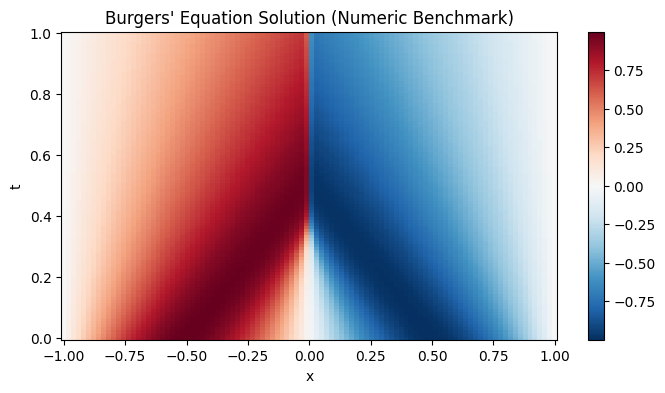

In [109]:
from scipy.interpolate import interp1d
# --- Numeric Benchmark Solution ---

n_grid = 100
x_grid = np.linspace(-L, L, n_grid)
t_grid = np.linspace(0, T, n_grid)
X, Tm = np.meshgrid(x_grid, t_grid)
xt_flat = np.stack([X.flatten(), Tm.flatten()], axis=1).astype(np.float32)

# Numeric Baseline (Dense for heatmaps)
sol_dense = solve_ivp(burgers_rhs, [0, T], u0_num, t_eval=t_grid, method='RK45')
u_exact_dense = np.zeros((n_grid, n_grid))
for i, t_val in enumerate(t_grid):
    f_interp = interp1d(x_num, sol_dense.y[:, i], kind='cubic', fill_value='extrapolate')
    u_exact_dense[i, :] = f_interp(x_grid)

plt.figure(figsize=(8, 4))
im = plt.pcolormesh(X, Tm, u_exact_dense, shading='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title("Burgers' Equation Solution (Numeric Benchmark)")
plt.colorbar(im)
plt.show()

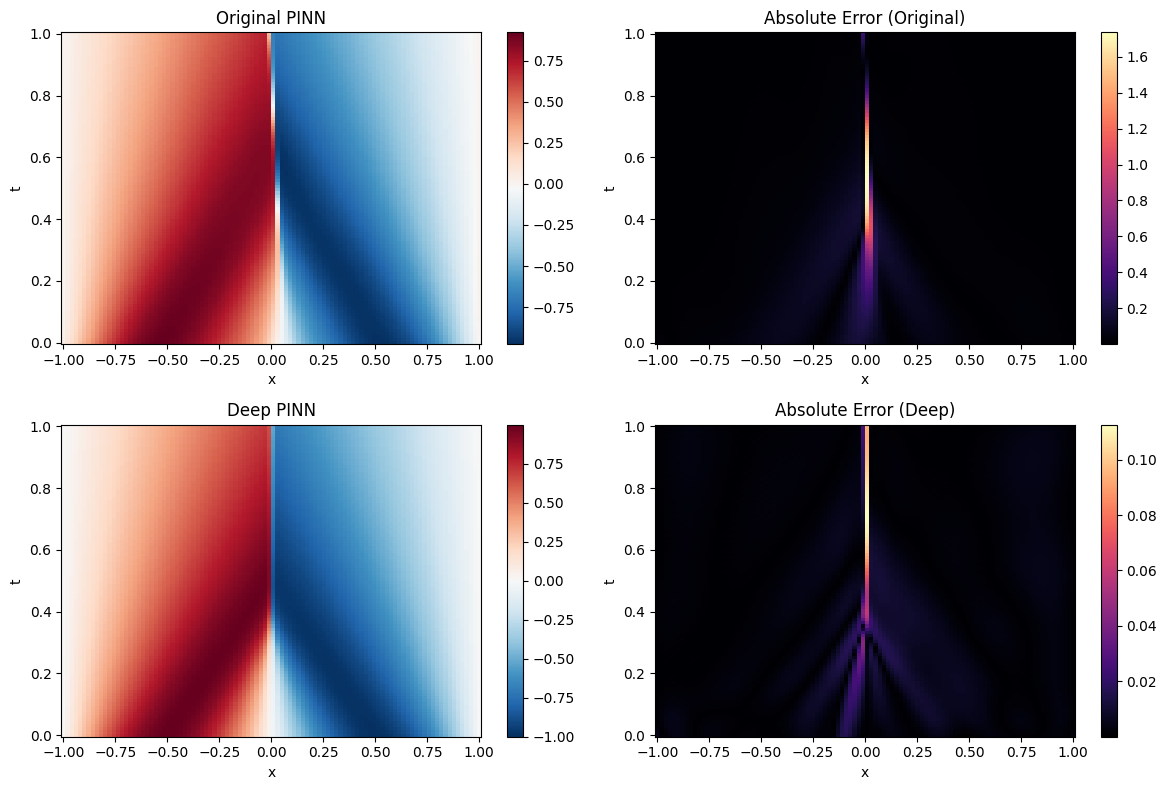

In [112]:
# PINN Predictions
u_shallow_pred = model_shallow(xt_flat).numpy().reshape(n_grid, n_grid)
u_deep_pred = model_deep(xt_flat).numpy().reshape(n_grid, n_grid)

# Absolute errors
error_shallow = np.abs(u_shallow_pred - u_exact_dense)
error_deep = np.abs(u_deep_pred - u_exact_dense)

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# -------------------------------
# Original PINN Solution
# -------------------------------
im1 = axes[0, 0].pcolormesh(
    X, Tm, u_shallow_pred,
    shading='auto',
    cmap='RdBu_r'
)
axes[0, 0].set_title("Original PINN")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("t")
fig.colorbar(im1, ax=axes[0, 0])

# -------------------------------
# Original PINN Error
# -------------------------------
im2 = axes[0, 1].pcolormesh(
    X, Tm, error_shallow,
    shading='auto',
    cmap='magma'
)
axes[0, 1].set_title("Absolute Error (Original)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("t")
fig.colorbar(im2, ax=axes[0, 1])

# -------------------------------
# Deep PINN Solution
# -------------------------------
im3 = axes[1, 0].pcolormesh(
    X, Tm, u_deep_pred,
    shading='auto',
    cmap='RdBu_r'
)
axes[1, 0].set_title("Deep PINN")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("t")
fig.colorbar(im3, ax=axes[1, 0])

# -------------------------------
# Deep PINN Error
# -------------------------------
im4 = axes[1, 1].pcolormesh(
    X, Tm, error_deep,
    shading='auto',
    cmap='magma'
)
axes[1, 1].set_title("Absolute Error (Deep)")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("t")
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### Exercise E. 

In [164]:
# FTCS grid
Nx = 100
dx = 1.0 / (Nx - 1)

dt_max = (dx**2) / (2 * ALPHA) # stability: dt <= dx^2 / (2 * alpha)
dt = dt_max * 0.9 # safety factor
Nt = int(np.ceil(1.0 / dt))
dt = 1.0 / Nt # recalculate dt to perfectly hit T=1.0

print(f"FTCS Grid: Nx={Nx}, Nt={Nt}, dx={dx:.4f}, dt={dt:.4f}")

u_ftcs = np.zeros(Nx)
x_ftcs = np.linspace(0, 1, Nx)

# IC
u_ftcs = np.sin(np.pi * x_ftcs) 

# BC
u_ftcs[0] = 0.0 
u_ftcs[-1] = 0.0

r = ALPHA * dt / (dx**2)

start_time = time.time()
for n in range(Nt):
    u_new = np.copy(u_ftcs)
    u_new[1:-1] = u_ftcs[1:-1] + r * (u_ftcs[2:] - 2*u_ftcs[1:-1] + u_ftcs[:-2])
    u_ftcs = u_new
ftcs_time = time.time() - start_time

u_exact_final = exact_solution(x_ftcs, 1.0)
ftcs_err = np.max(np.abs(u_ftcs - u_exact_final))

print(f"FTCS Wall-clock time: {ftcs_time:.4f} seconds")
print(f"FTCS Max Absolute Error at t=1.0: {ftcs_err:.4e}")


FTCS Grid: Nx=100, Nt=2178, dx=0.0101, dt=0.0005
FTCS Wall-clock time: 0.0277 seconds
FTCS Max Absolute Error at t=1.0: 5.2478e-05


In [162]:
xt_pinn = np.stack([x_ftcs, np.full_like(x_ftcs, 1.0)], axis=1).astype(np.float32)

# PINN inference time
start_time = time.time()
model = models[(1, 10, 10)] # from exercise B
u_pinn = model(xt_pinn).numpy().flatten()
pinn_time = time.time() - start_time

# PINN error
pinn_err = np.max(np.abs(u_pinn - u_exact_final))

print(f"PINN Inference time: {pinn_time:.4f} seconds")
print(f"PINN Max Absolute Error at t=1.0: {pinn_err:.4e}")

PINN Inference time: 0.0081 seconds
PINN Max Absolute Error at t=1.0: 5.5522e-03


-- Comparison --
           Method  Time (s)  Max Error
   FTCS (Numeric)  0.019125   0.000052
PINN (Neural Net)  0.008054   0.005552


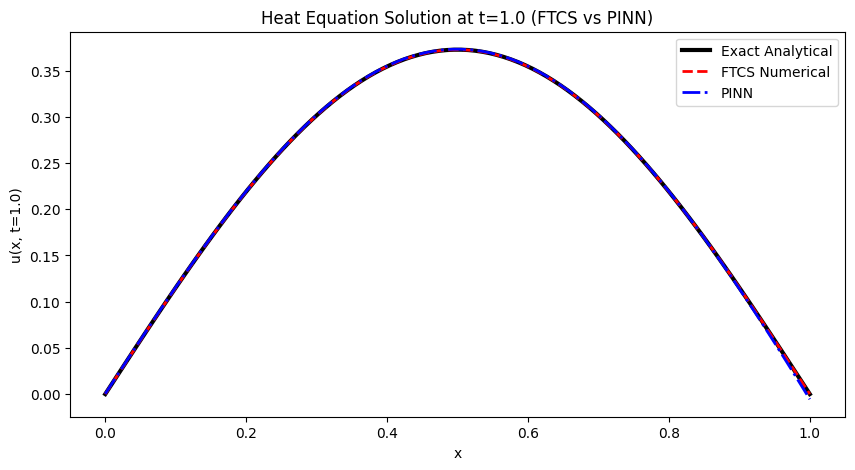

In [163]:
# comparison
import pandas as pd
df = pd.DataFrame({
    'Method': ['FTCS (Numeric)', 'PINN (Neural Net)'],
    'Time (s)': [ftcs_time, pinn_time],
    'Max Error': [ftcs_err, pinn_err]
})
print("-- Comparison --")
print(df.to_string(index=False))

# plot
plt.figure(figsize=(10, 5))
plt.plot(x_ftcs, u_exact_final, 'k-', linewidth=3, label='Exact Analytical')
plt.plot(x_ftcs, u_ftcs, 'r--', linewidth=2, label='FTCS Numerical')
plt.plot(x_ftcs, u_pinn, 'b-.', linewidth=2, label='PINN')
plt.title("Heat Equation Solution at t=1.0 (FTCS vs PINN)")
plt.xlabel("x")
plt.ylabel("u(x, t=1.0)")
plt.legend()
plt.show()
